In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import cross_val_score

In [3]:
df = pd.read_csv("StudentPerformanceFactors.csv")
df.head(6)

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70
5,19,88,Medium,Medium,Yes,8,89,Medium,Yes,3,Medium,Medium,Public,Positive,3,No,Postgraduate,Near,Male,71


In [4]:
def uniqueValue(df , *args):
    for column in args:
        print(column)
        print("="*50)
        print(df[column].unique())
        print()

uniqueValue(df, "Parental_Involvement","Access_to_Resources","Extracurricular_Activities",
            "Motivation_Level","Family_Income","Internet_Access","Teacher_Quality","Peer_Influence",
            "Learning_Disabilities","Parental_Education_Level",'Distance_from_Home','Gender',"School_Type","Distance_from_Home"
           
           )

Parental_Involvement
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Access_to_Resources
<StringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str

Extracurricular_Activities
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Motivation_Level
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Family_Income
<StringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str

Internet_Access
<StringArray>
['Yes', 'No']
Length: 2, dtype: str

Teacher_Quality
<StringArray>
['Medium', 'High', 'Low', nan]
Length: 4, dtype: str

Peer_Influence
<StringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str

Learning_Disabilities
<StringArray>
['No', 'Yes']
Length: 2, dtype: str

Parental_Education_Level
<StringArray>
['High School', 'College', 'Postgraduate', nan]
Length: 4, dtype: str

Distance_from_Home
<StringArray>
['Near', 'Moderate', 'Far', nan]
Length: 4, dtype: str

Gender
<StringArray>
['Male', 'Female']
Length: 2, dtype: str

School_Type
<StringArray

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

In [6]:
df.isna().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [7]:
X=df.drop(columns=['Exam_Score'])
y=df['Exam_Score']
X

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6602,25,69,High,Medium,No,7,76,Medium,Yes,1,High,Medium,Public,Positive,2,No,High School,Near,Female
6603,23,76,High,Medium,No,8,81,Medium,Yes,3,Low,High,Public,Positive,2,No,High School,Near,Female
6604,20,90,Medium,Low,Yes,6,65,Low,Yes,3,Low,Medium,Public,Negative,2,No,Postgraduate,Near,Female
6605,10,86,High,High,Yes,6,91,High,Yes,2,Low,Medium,Private,Positive,3,No,High School,Far,Female


In [8]:
X_train , X_test , y_train , y_test =train_test_split(X,y,test_size=0.25,random_state=42)
print(X_train.shape , X_test.shape , y_train.shape , y_test.shape )

(4955, 19) (1652, 19) (4955,) (1652,)


In [9]:
df['Attendance'].skew()

np.float64(0.013665859547014896)

TypeError: The x variable is categorical, but one of ['numeric', 'datetime'] is required

<Figure size 800x400 with 0 Axes>

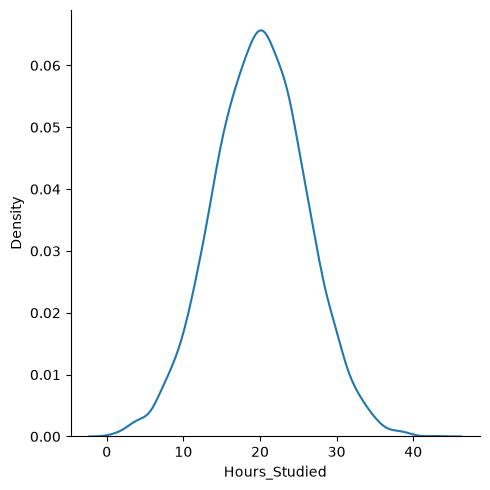

<Figure size 800x400 with 0 Axes>

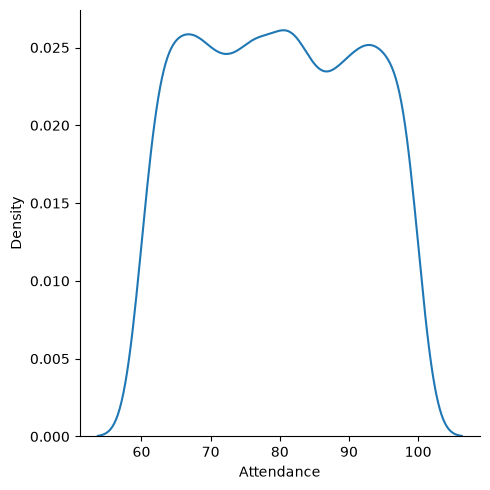

<Figure size 800x400 with 0 Axes>

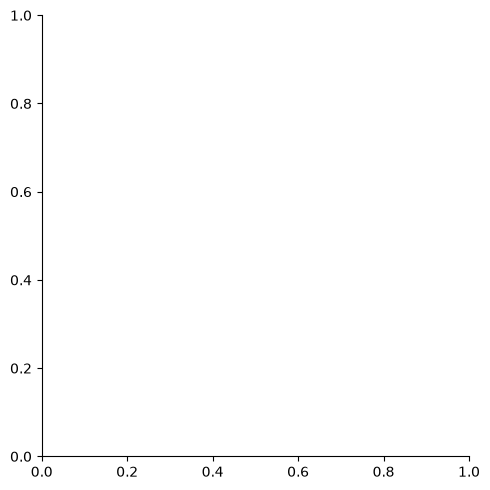

In [10]:
def graphs(df, *args):
    for column in args:
        plt.figure(figsize=(8, 4))
        sns.displot(df[column],kind='kde')

graphs(X_train,*X_train.columns)

In [ ]:
df['Tutoring_Sessions'].skew()

In [ ]:
sns.distplot(df['Tutoring_Sessions'])

In [ ]:
def outlierss(df,df1, *args):
    for column in args:
        q1=df[column].quantile(0.25)
        q3=df[column].quantile(0.75)
        q11=df[column].quantile(0.25)
        q31=df[column].quantile(0.75)
        iqr=q3-q1
        iqr1=q31-q11
        lower_bound =q1-1.5*iqr
        upper_bound=q3+1.5*iqr
        lower_bound1 =q1-1.5*iqr
        upper_bound1=q3+1.5*iqr
        outlier = df[(df[column]<lower_bound ) |(df[column]>upper_bound)]
        df[column] = df[column].clip(lower=lower_bound, upper=upper_bound) 
        df1[column] = df1[column].clip(lower=lower_bound1, upper=upper_bound1)
       

        

outlierss(X_train,X_test,"Tutoring_Sessions","Attendance","Hours_Studied")

In [ ]:
def boxplott(df, *args):
    for column in args:
        sns.boxplot(x=df[column])
        plt.title(column)
        plt.show()
boxplott(X_train,"Tutoring_Sessions","Attendance","Hours_Studied")

In [12]:
from sklearn.pipeline import Pipeline

ordinal_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OrdinalEncoder(categories=[
        ['Low', 'Medium', 'High'],
        ['Low', 'Medium', 'High'],
        ['Low', 'Medium', 'High'],
        ['Low', 'Medium', 'High'],
        ['Low', 'Medium', 'High'],
        ['No', 'Yes'],
        ['No', 'Yes'],
        ['No', 'Yes'],
        ['High School', 'College', 'Postgraduate']
        
    ]))
])

onehot_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

ct = ColumnTransformer(
    transformers=[
        ("ordinal", ordinal_pipe,
         [2, 3, 7, 10, 11, 4, 8, 15, 16,]),

        ("onehot", onehot_pipe, [18,12,17,13])
    ],
    remainder="passthrough"
)

In [13]:
pipe = Pipeline([
    ("preprocessor", ct),
    ("model", LinearRegression())
])
pipe.fit(X_train,y_train)
y_pred=pipe.predict(X_test)

datas = [
  {
      "test Value":y_test,
      "Predicted Value":y_pred.round(2)
  }


]
actualvspred_df = pd.DataFrame(datas).to_string(index=False)
print(actualvspred_df)

                                                                                                                                                           test Value                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                       Predicted Value
743     65
5551    65
3442    71
6571    64
4204    66
        ..
184     69
71      71
5394    63
711     70
421     72
Name: Exam_Score, L

In [14]:
print(f"r_2 Score is ={r2_score(y_test,y_pred)}")

r_2 Score is =0.7853764656652753


In [15]:
b= pipe.named_steps['model'].intercept_

In [16]:
m=pipe.named_steps['model'].coef_


In [17]:


scores = cross_val_score(
    pipe,
    X,
    y,
    cv=10,
    scoring="r2"
)

print("R² Scores:", scores)
print("Average R²:", scores.mean())
print("Standard Deviation:", scores.std())

R² Scores: [0.60381228 0.64800612 0.77827848 0.67315492 0.67384056 0.74229237
 0.66374215 0.82700295 0.98648862 0.73338573]
Average R²: 0.7330004189083642
Standard Deviation: 0.10536651238084341


In [18]:
import pandas as pd

new_record = pd.DataFrame({
    "Hours_Studied": [8],
    "Attendance": [10],
    "Parental_Involvement": ["High"],
    "Access_to_Resources": ["Medium"],
    "Extracurricular_Activities": ["No"],
    "Sleep_Hours": [7],
    "Previous_Scores": [60],
    "Motivation_Level": ["High"],
    "Internet_Access": ["Yes"],
    "Tutoring_Sessions": [1],
    "Family_Income": ["Low"],
    "Teacher_Quality": ["High"],
    "School_Type": ["Private"],
    "Peer_Influence": ["Negative"],
    "Physical_Activity": [4],
    "Learning_Disabilities": ["No"],
    "Parental_Education_Level": ["College"],
    "Distance_from_Home": ["Far"],
    "Gender": ["Female"]
})

prediction = pipe.predict(new_record)
print("Predicted Exam Score:", prediction[0])

Predicted Exam Score: 49.09949463432329


In [20]:
import pickle
with open("student_performance_pipeline.pkl", "wb") as file:
    pickle.dump(pipe, file)

print("Pipeline saved successfully!")

Pipeline saved successfully!
